# Back Propagation Net


## Entorno de desarrollo

Este trabajo fue realizado en Google Colab utilizando la versión 3.13.15 de Python y las siguientes versiones de librerías externas:
* gdown 5.2.2
* numpy 2.1.3
* matplotlib 3.10.0

## Librerías

In [19]:
# Descargar librerías externas
!pip install pandas==2.2.3 numpy==2.1.3 matplotlib==3.10.0 openpyxl==3.1.5 --quiet

In [20]:
# Importar librerías externas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Math

## Problema ficticio

En la universidad últimamente estamos notando que una gran cantidad de estudiantes están empezando a salir mal en la materia Análisis Matemático I. El objetivo de este proyecto es revertir esta tendencia y lograr que aprueben, identificando a tiempo quiénes están en riesgo.

Del año pasado, tenemos algunos datos sobre 1000 alumnos que cursaron Análisis Matemático I en la UTN de Buenos Aires. Esos datos son:
* Horas de estudio semanalas dedicadas a AM I.
* Porcentaje total de presentismo en las clases.
* Horas de sueño promedio.
* Nota promedio en los TPs.

Y para cada uno de ellos sabemos si aprobó AM I o desaprobó.

También poseemos estos datos de entrada para los 100 alumnos que están cursando AM I en la UTN de Concepción del Uruguay, pero falta 1 mes para que rindan el exámen y queremos saber quienes tienen mayor tendencia a desaprobar para brindarles especial atención y lograr que aprueben.

## Arquitectura de la solución

Para resolver este problema construiremos una red neuronal.

Esta red neuronal tomará como entrada:
* Horas de estudio semanalas dedicadas a AM I.
* Porcentaje total de presentismo en las clases.
* Horas de sueño promedio.
* Nota promedio en los TPs.

Y devolverá la probabilidad que tiene el estudiante de aprobar.

Entonces, la estructura de esta red neuronal será:
* 1 capa de entrada (4 neuronas)
* 2 capas ocultas (6 neuronas la primera y 3 neuronas la segunda)
* 1 capa de salida (1 neurona)

## Estructura de la red neuronal

Así se ve la estructura de la red neuronal que construiremos

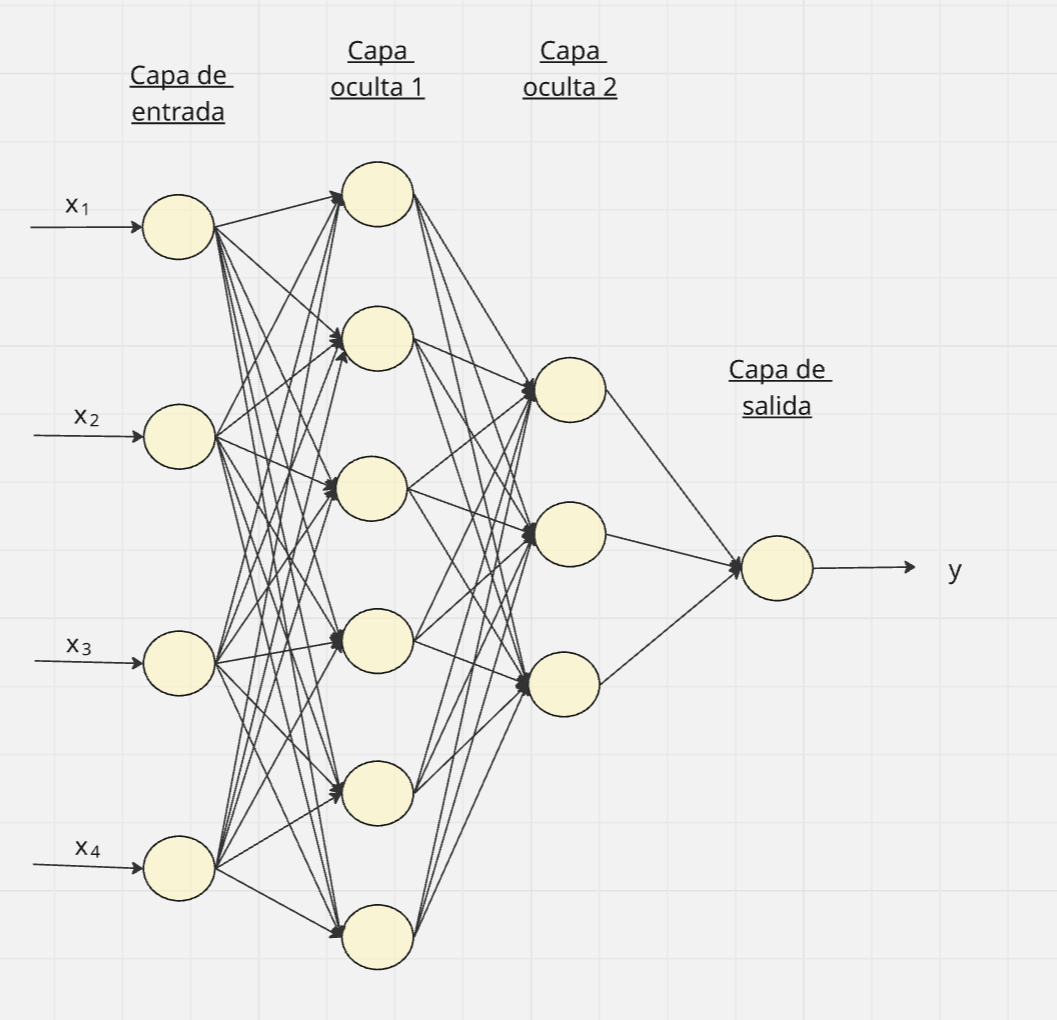

In [21]:
display(Image('bpn-estructura-red.png', width=600))

## Solución

### Carga de datos sobre alumnos de la UTN de Buenos Aires

Cargamos los datos tanto de los 1000 alumnos de la UTN de Buenos Aires en un dataframe de la librería Pandas.

In [22]:
df_bsas = pd.read_excel('alumnos-utn-bsas.xlsx')
df_frcu = pd.read_excel('alumnos-utn-frcu.xlsx')

# Visualización de los datos
display(df_bsas.head(5))
print('')
display(df_frcu.head(5))

,Horas_Estudio,Asistencia_Pct,Horas_Sueno,Nota_TPs,Aprobado
0,7.5,51.1,4.6,7.4,1
1,19.0,72.5,4.5,8.4,1
2,14.6,92.4,8.4,4.0,1
3,12.0,83.9,4.5,7.0,1
4,3.1,88.4,4.6,6.6,1


,Horas_Estudio,Asistencia_Pct,Horas_Sueno,Nota_TPs
0,11.2,72.6,3.4,4.1
1,1.1,81.7,4.9,4.2
2,19.4,70.9,4.6,9.4
3,10.3,99.4,6.0,2.2
4,5.8,76.7,7.7,7.6


### División del dataset en entradas (X) y salidas esperadas (Y)

#### Estructura de Entradas (X)


$$X_{BSAS} = \begin{bmatrix} x_{1,1} & x_{1,2} & x_{1,3} & x_{1,4} \\ x_{2,1} & x_{2,2} & x_{2,3} & x_{2,4} \\ \vdots & \vdots & \vdots & \vdots \\ x_{1000,1} & x_{1000,2} & x_{1000,3} & x_{1000,4} \end{bmatrix}$$

$$X_{FRCU} = \begin{bmatrix} x_{1,1} & x_{1,2} & x_{1,3} & x_{1,4} \\ x_{2,1} & x_{2,2} & x_{2,3} & x_{2,4} \\ \vdots & \vdots & \vdots & \vdots \\ x_{1000,1} & x_{1000,2} & x_{1000,3} & x_{1000,4} \end{bmatrix}$$

#### Estructura de Salida (Y)


$$Y_{BSAS} = \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_{1000} \end{bmatrix}$$

#### Código

In [23]:
X_bsas = df_bsas.drop('Aprobado', axis=1).values    # No solo sacamos la columna "Aprobado", sino que transformamos el DF en matriz 1000x4
X_frcu = df_frcu.values                             # No solo sacamos la columna "Aprobado", sino que transformamos el DF en matriz 1000x4
Y_bsas = df_bsas['Aprobado'].values.reshape(-1, 1)  # No solo separamos la columna "Aprobado", sino que transformamos el DF en matriz 1000x1

### Crear estructura de la red neuronal

Ahora crearemos la estructura de la red neuronal, inicializando los pesos de las conexiones (w) en valores aleatorios, los sesgos (b) en 0 y definimos las funciones de activación de las neuronas (ReLU para las capas ocultas y Sigmoide para la capa de salida para que devuelva valores entre 0 (desaprobado) y 1 (aprobado), que representarán la probabilidad de aprobar del alumno) junto con sus derivadas. Además, definiremos la función del error total, para la cuál utilizaremos la función de error cuadrático medio (MSE). Y necesitaremos la derivada de ese MSE.

#### Función ReLU (capas ocultas)

$$f(x) = \max(0, x)$$

#### Función ReLU derivada

$$f'(x) = \begin{cases} 1 & \text{si } x > 0 \\ 0 & \text{si } x \le 0 \end{cases}$$

#### Función Sigmoide (capa de salida)

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

#### Función Sigmoide derivada

$$\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x))$$

#### Función de error cuadrático medio (MSE)

$$E = \frac{1}{2} (y_d - y)^2$$

#### Matrices de Pesos ($W$)

$$W_1 = \begin{bmatrix} w^{(1)}_{1,1} & w^{(1)}_{1,2} & \dots & w^{(1)}_{1,6} \\ w^{(1)}_{2,1} & w^{(1)}_{2,2} & \dots & w^{(1)}_{2,6} \\ \vdots & \vdots & \ddots & \vdots \\ w^{(1)}_{4,1} & w^{(1)}_{4,2} & \dots & w^{(1)}_{4,6} \end{bmatrix}$$

$$W_2 = \begin{bmatrix} w^{(2)}_{1,1} & w^{(2)}_{1,2} & w^{(2)}_{1,3} \\ w^{(2)}_{2,1} & w^{(2)}_{2,2} & w^{(2)}_{2,3} \\ \vdots & \vdots & \vdots \\ w^{(2)}_{6,1} & w^{(2)}_{6,2} & w^{(2)}_{6,3} \end{bmatrix}$$

$$W_3 = \begin{bmatrix} w^{(3)}_{1,1} \\ w^{(3)}_{2,1} \\ w^{(3)}_{3,1} \end{bmatrix}$$

#### Vectores de Sesgo ($B$)

$$B_1 = \begin{bmatrix} B^{(1)}_1 & B^{(1)}_2 & B^{(1)}_3 & B^{(1)}_4 & B^{(1)}_5 & B^{(1)}_6 \end{bmatrix}$$

$$B_2 = \begin{bmatrix} B^{(2)}_1 & B^{(2)}_2 & B^{(2)}_3 \end{bmatrix}$$

$$B_3 = \begin{bmatrix} B^{(3)}_1 \end{bmatrix}$$

#### Código

In [24]:
np.random.seed(42)   # Para reproducibilidad

# Tamaño de cada capa
n_entrada = 4
n_oculta1 = 6
n_oculta2 = 3
n_salida = 1

# Inicializamos los Pesos (W) aleatorios y los Sesgos (b) en cero
# ENTRADA -> OCULTA 1
W1 = np.random.randn(n_entrada, n_oculta1) * 0.1
B1 = np.zeros((1, n_oculta1))

# OCULTA 1 -> OCULTA 2
W2 = np.random.randn(n_oculta1, n_oculta2) * 0.1
B2 = np.zeros((1, n_oculta2))

# OCULTA 2 -> SALIDA
W3 = np.random.randn(n_oculta2, n_salida) * 0.1
B3 = np.zeros((1, n_salida))

# FUNCIONES DE ACTIVACIÓN
# Función ReLU y su derivada
def relu(y):
    return np.maximum(0, y)

def relu_derivada(y):
    return y > 0  # Devuelve True (1) si es positivo, False (0) si es negativo o cero

# Función Sigmoide y su derivada
def sigmoide(y):
    y = np.clip(y, -500, 500)   # Recortamos Z si llega a dar un valor muy grande, para evitar errores
    return 1 / (1 + np.exp(-y))

def sigmoide_derivada(y):
    sig = sigmoide(y)
    return sig * (1 - sig)

# Función MSE
def mse(y_deseada, y_predicha):
    return np.mean(0.5 * (y_deseada - y_predicha)**2)


### Crear lógica del flujo forward y backward

#### Flujo Forward

##### Explicación

Básicamente consiste en tomar un dato x y pasarlo por la red neuronal, capa por capa. Primero se calcula la suma neta que se obtiene en cada neurona de la capa oculta 1:

$$SN_1 = X \cdot W_1 + B_1$$

Que al desglosar las matrices se vería así se vería así:

$$
\begin{bmatrix}
SN^{(1)}_1 & SN^{(1)}_2 & \dots & SN^{(1)}_6
\end{bmatrix} =
\begin{bmatrix}
x_1 & x_2 & x_3 & x_4
\end{bmatrix}
\cdot
\begin{bmatrix}
w^{(1)}_{1,1} & w^{(1)}_{1,2} & \dots & w^{(1)}_{1,6} \\
w^{(1)}_{2,1} & w^{(1)}_{2,2} & \dots & w^{(1)}_{2,6} \\
w^{(1)}_{3,1} & w^{(1)}_{3,2} & \dots & w^{(1)}_{3,6} \\
w^{(1)}_{4,1} & w^{(1)}_{4,2} & \dots & w^{(1)}_{4,6}
\end{bmatrix}
+
\begin{bmatrix}
B^{(1)}_1 & B^{(1)}_2 & \dots & B^{(1)}_6
\end{bmatrix}
$$

A ese vector de sumas netas SN se lo pasa por la función de activación ReLU, y esos valores son los que pasan a la siguiente capa, en la que se repite la misma operacion matricial reemplazando los 4 valores de x por los de SN, y así hasta llegar a la última capa, en la que la diferencia es que la función de activación es la Sigmoide.

##### Código

In [25]:
def capa_forward(entradas, W, B, funcion_activacion):
    SN = entradas @ W + B          # Suma neta
    FA = funcion_activacion(SN)    # Función de activación
    return SN, FA

def forward_pass(x, W1, b1, W2, b2, W3, b3):
    SN1, FA1 = capa_forward(x, W1, b1, relu)       # Capa Oculta 1
    SN2, FA2 = capa_forward(FA1, W2, b2, relu)     # Capa Oculta 2
    SN3, Y = capa_forward(FA2, W3, b3, sigmoide) # Capa de Salida
    memoria = (SN1, FA1, SN2, FA2, SN3, Y)       # Guardamos todos los valores calculados porque los necesitamos para BP
    return Y, memoria

#### Flujo Backward (con BP)

##### Explicación

Consiste en calcular cuánto contribuyó cada peso w y cada sesgo b en el error total, para luego reajustar esos parámetros w y b para disminuir el error de la salida de la red. Para ello, primero calcularemos los errores locales capa por capa. El vector de errores locales de una capa de la red se calcula dependiendo de si estamos en la capa de salida o en alguna capa oculta. La fórmula para calcular el error local en la capa de salida, dado que estamos usando el MSE como error total, es:

$${E}_{local \ capa \ salida} = (y - y_{deseado}) \odot F'_{salida}(SN_{salida})$$

Que matricialmente se vería así en nuestro caso se vería así:


$$
\begin{bmatrix}
{E}_{local \ neurona \ salida}
\end{bmatrix} =
\left(
\begin{bmatrix}
y
\end{bmatrix}
-
\begin{bmatrix}
y_{deseada}
\end{bmatrix}
\right)
\odot
\begin{bmatrix}
F'_{salida}(SN_{salida})
\end{bmatrix}
$$


Esto sucede porque tenemos una sola neurona de salida. Y para calcular el resto de errores locales, utilizaremos la siguiente fórmula:

$${E}_{local \ capa \ N} = ({E}_{local \ capa \ N+1} \cdot W_{N+1}) \odot F'_N(SN_{capa \ N})$$

Que, por ejemplo, matricialmente para la segunda capa oculta nos quedaría:

$$
\small
\begin{bmatrix}
{E}_{local \ capa \ 2_1} & {E}_{local \ capa \ 2_2} & {E}_{local \ capa \ 2_3}
\end{bmatrix} =
\left(
\begin{bmatrix}
{E}_{local \ capa \ 3_1}
\end{bmatrix}
\cdot
\begin{bmatrix}
w^{(3)}_{1,1} & w^{(3)}_{2,1} & w^{(3)}_{3,1}
\end{bmatrix}
\right)
\odot
\begin{bmatrix}
F'_{2}(SN_{capa \ 2_1}) & F'_{2}(SN_{capa \ 2_2}) & F'_{2}(SN_{capa \ 2_3})
\end{bmatrix}
$$

Ya sabiendo cómo calcular los errores locales, el ajuste de pesos y sesgos se realizará una vez calculados todos los errores locales, utilizando las siguientes fórmulas:

$$ W_N = W_N - \eta \cdot \left(F(x)_{capa \ N-1} \cdot {E}_{local \ capa \ N} \right) $$

$$ B_N = B_N - \eta \cdot {E}_{local \ capa \ N} $$

Siendo:
* η: Tasa de aprendizaje.
* x: Dato que ingresó a la red.
* F(x) de la capa N-1: Salidas de la capa N-1 obtenidas con el dato x.

Y matricialmente, la actualización de W2 (por mencionar una capa de ejemplo) se vería así:

$$
\begin{bmatrix}
w_{1,1} & w_{1,2} & w_{1,3} \\
w_{2,1} & w_{2,2} & w_{2,3} \\
w_{3,1} & w_{3,2} & w_{3,3} \\
w_{4,1} & w_{4,2} & w_{4,3} \\
w_{5,1} & w_{5,2} & w_{5,3} \\
w_{6,1} & w_{6,2} & w_{6,3}
\end{bmatrix} =
\begin{bmatrix}
w_{1,1} & w_{1,2} & w_{1,3} \\
w_{2,1} & w_{2,2} & w_{2,3} \\
w_{3,1} & w_{3,2} & w_{3,3} \\
w_{4,1} & w_{4,2} & w_{4,3} \\
w_{5,1} & w_{5,2} & w_{5,3} \\
w_{6,1} & w_{6,2} & w_{6,3}
\end{bmatrix}
- \eta \cdot
\left(
\begin{bmatrix}
F(x)_{capa \ 1_1} \\
F(x)_{capa \ 1_2} \\
F(x)_{capa \ 1_3} \\
F(x)_{capa \ 1_4} \\
F(x)_{capa \ 1_5} \\
F(x)_{capa \ 1_6}
\end{bmatrix}
\cdot
\begin{bmatrix}
E_{local \ capa \ 2_1} & E_{local \ capa \ 2_2} & E_{local \ capa \ 2_3}
\end{bmatrix}
\right)
$$

Y la actualización de B2 se vería así:

$$
\begin{bmatrix}
b_1 & b_2 & b_3
\end{bmatrix} =
\begin{bmatrix}
b_1 & b_2 & b_3
\end{bmatrix}
- \eta \cdot
\begin{bmatrix}
E_{local \ capa \ 2_1} & E_{local \ capa \ 2_2} & E_{local \ capa \ 2_3}
\end{bmatrix}
$$

Además, en cada época t actualizaremos la tasa de aprendizaje, para que disminuya gradualmente a medida que los pesos se van ajustando:


$$ \eta_{actual} = \eta_{0} \cdot e^{-t/T} $$

Siendo:
* η0: Tasa de aprendizaje inicial.
* t: Época de entrenamiento actual.
* T: Épocas de entrenamiento a realizar.

##### Código

In [26]:
# Calcular error local capa de salida
def error_local_salida(y, y_deseado, SN):
    error_local = (y - y_deseado) * sigmoide_derivada(SN)
    return error_local

# Calcular error local capas ocultas
def error_local_oculta(error_local_siguiente, W_siguiente, SN_actual):
    error_local = (error_local_siguiente @ W_siguiente.T) * relu_derivada(SN_actual)
    return error_local

# Actualizar parámetros
def actualizar_parametros(W, B, F_anterior, error_local, eta):
    W_nuevo = W - (eta * (F_anterior.T @ error_local))
    B_nuevo = B - (eta * error_local)
    return W_nuevo, B_nuevo

# Actualizar tasa de aprendizaje
def actualizar_eta(eta_inicial, epocas_totales, epoca_actual):
    eta_actual = eta_inicial * np.exp(-epoca_actual / epocas_totales)
    return eta_actual

def backward_pass(x, y_deseado, W1, b1, W2, b2, W3, b3, memoria, eta):
    # Desempaquetamos la memoria guardada en el forward pass
    SN1, FA1, SN2, FA2, SN3, y = memoria

    # Errores locales de cada capa
    E_local_3 = error_local_salida(y, y_deseado, SN3)
    E_local_2 = error_local_oculta(E_local_3, W3, SN2)
    E_local_1 = error_local_oculta(E_local_2, W2, SN1)

    # Actualizamos pesos W y sesgos B
    W3_nuevo, b3_nuevo = actualizar_parametros(W3, b3, FA2, E_local_3, eta)
    W2_nuevo, b2_nuevo = actualizar_parametros(W2, b2, FA1, E_local_2, eta)
    W1_nuevo, b1_nuevo = actualizar_parametros(W1, b1, x, E_local_1, eta)

    # Devolvemos las nuevas matrices de pesos y sesgos
    return W1_nuevo, b1_nuevo, W2_nuevo, b2_nuevo, W3_nuevo, b3_nuevo

### Entrenamiento y testing

Ahora procederemos a entrenar la red con los datos de los alumnos de la UTN de Buenos Aires. Para ello, inicialmente dividiremos el dataset en train set (800) y test set (200), para de alguna forma poder validar va que el modelo realmente aprendió el patrón detrás de los datos y no memorizó los datos sin entender su trasfondo. Esta proporción (80% train set y 20% test set) es estándar.

In [27]:
def entrenar_red(X, Y_deseados, W1, b1, W2, b2, W3, b3, T, eta_inicial):
    errores_historial = []

    for t in range(T):
        error_epoca = 0
        eta_actual = actualizar_eta(eta_inicial, T, t)   # Actualizamos tasa de aprendizaje η

        # Iteramos alumno por alumno
        for i in range(len(X)):

            x_actual = X[i:i+1]                                            # Tomamos de la matriz de datos el dato en cuestión
            y_deseado_actual = Y_deseados[i:i+1]                           # Tomamos de la matriz de salidas la salida deseada de ese dato
            y, memoria = forward_pass(x_actual, W1, b1, W2, b2, W3, b3)    # Flujo Forward
            error_epoca += mse(y_deseado_actual, y)                        # Calculamos el error total

            W1, b1, W2, b2, W3, b3 = backward_pass(x_actual, y_deseado_actual, W1, b1, W2, b2, W3, b3, memoria, eta_actual)

        # Calculamos el error promedio de esta época T y lo guardamos
        error_promedio = error_epoca / len(X)
        errores_historial.append(error_promedio)

    return W1, b1, W2, b2, W3, b3, errores_historial

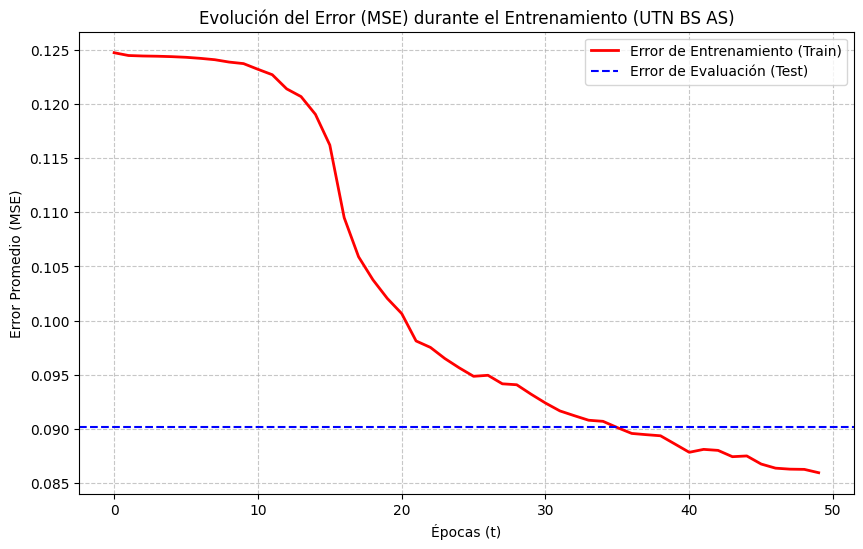

In [28]:
# División de los datos en Train (800) y Test (200)
X_train = X_bsas[:800]
Y_train = Y_bsas[:800]

X_test = X_bsas[800:]
Y_test = Y_bsas[800:]

T = 50              # Número de épocas de entrenamiento
eta_inicial = 0.03  # Tasa de aprendizaje inicial

# Entrenamos con los 800 datos de Train
W1_opt, B1_opt, W2_opt, B2_opt, W3_opt, B3_opt, historial = entrenar_red(
    X_train, Y_train,
    W1, B1, W2, B2, W3, B3,
    T, eta_inicial
)

# Evaluamos la red con los 200 datos de Test (datos que la red nunca vio)
probabilidades_test, _ = forward_pass(X_test, W1_opt, B1_opt, W2_opt, B2_opt, W3_opt, B3_opt)
error_test = mse(Y_test, probabilidades_test)

# 4. GRAFICAR CURVAS DE ERROR
plt.figure(figsize=(10, 6))
plt.plot(historial, color='red', linewidth=2, label='Error de Entrenamiento (Train)')
plt.axhline(y=error_test, color='blue', linestyle='--', label='Error de Evaluación (Test)')
plt.title('Evolución del Error (MSE) durante el Entrenamiento (UTN BS AS)')
plt.xlabel('Épocas (t)')
plt.ylabel('Error Promedio (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

La red neuronal ha mostrado una mejora notoria y logró reducir el error cuadrático medio en gran medida, además de mostrar buenos resultados con los datos del test set nunca antes visto (MSE_TEST=0.09, MSE_TRAIN=0.085). Esta diferencia tan pequeña nos muestra que la red aprendió el comportamiento de los datos. No es que memorizó los 800 estudiantes, sino que entendió en qué circunstancias aprueban y en qué circunstancias desaprueban. La red logró:
* Generalización perfecta: La diferencia entre el error de los datos que la red estudió (Train) y los datos que la red nunca había visto (Test) es mínima (apenas 0.01 de diferencia).
* Aprendió las reglas, no de memoria: Si la red se hubiera "aprendido de memoria" a los 800 alumnos de Buenos Aires, el error de Test te hubiera dado altísimo (por ejemplo, 0.30 o 0.40). Al dar 0.09, demuestra que entendió la lógica de fondo de tu problema.
* Predicciones confiables: Con estas métricas, podemos confiar bastante en que el filtrado que hagamos de los 100 alumnos de CDELU será sólido.

### Predicción sobre alumnos UTN FRCU

Ahora ya está lista para predecir qué alumnos de UTN FRCU que están cursando AM I están en riesgo de desaprobar el próximo exámen

In [29]:
probabilidades, _ = forward_pass(X_frcu, W1_opt, B1_opt, W2_opt, B2_opt, W3_opt, B3_opt)  # Pasamos todos los datos de FRCU por la red ya entrenada
df_frcu['Probabilidad_Aprobar'] = probabilidades                                          # Agregamos las probabilidades de aprobar al dataframe
df_frcu['En_Riesgo'] = df_frcu['Probabilidad_Aprobar'] < 0.4                              # Definimos que si la probabilidad es menor al 40%, el alumno está en riesgo de desaprobar
alumnos_en_riesgo = df_frcu[df_frcu['En_Riesgo'] == True]                                 # Filtramos el dataframe y nos quedamos solo con los que necesitan ayuda
display(alumnos_en_riesgo.sort_values(by='Probabilidad_Aprobar'))

,Horas_Estudio,Asistencia_Pct,Horas_Sueno,Nota_TPs,Probabilidad_Aprobar,En_Riesgo
80,1.8,48.0,8.2,4.6,0.058693,True
71,6.1,43.8,7.8,3.5,0.100664,True
7,6.1,50.2,5.2,9.8,0.122391,True
54,5.6,61.2,7.8,9.0,0.136467,True
8,3.9,63.1,7.1,9.8,0.136794,True
99,4.5,54.5,9.0,2.8,0.137931,True
90,5.8,52.8,8.7,3.6,0.138370,True
20,3.6,55.7,5.7,8.6,0.141658,True
15,6.7,60.5,7.2,9.9,0.152046,True
59,5.6,58.6,6.5,9.3,0.156885,True


Estos son los alumnos que necesitan especial atención en la materia de AM I en UTN FRCU, pues es bastante probable que desaprueben el próximo exámen.

## Créditos

* Dataset de alumnos de UTN BS AS y FRCU: Generada por el mismo autor mediante Claude.
* Imágen de la estructura de la red neuronal: Elaborada por el autor con el SW online Miro.